# Iris Flower Classification Using Neural Network

## Mini Project — Deep Learning & Neural Networks

**Domain:** Artificial Intelligence  
**Project:** Iris Flower Classification  
**Model:** Artificial Neural Network (ANN)  
**Framework:** TensorFlow / Keras

### Objective

The objective of this mini project is to build an Artificial Neural Network (ANN) capable of classifying Iris flowers into three different species based on their physical measurements.

The project demonstrates the complete machine learning workflow, including dataset loading, data exploration, preprocessing, train-test splitting, feature scaling, neural network construction, model training, prediction, evaluation, and visualization.

## 1. Problem Statement

The Iris flower dataset contains measurements of flowers belonging to three different species: **Iris setosa, Iris versicolor, and Iris virginica**.

The objective of this project is to develop a neural network classification model that can predict the species of an Iris flower based on four input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The trained model will be evaluated using test accuracy, precision, recall, F1-score, predictions, and a confusion matrix.

## 2. Dataset Description

The Iris dataset is a well-known dataset commonly used for demonstrating classification algorithms and machine learning concepts.

It contains **150 samples** belonging to **3 classes**, with **50 samples per class**.

### Input Features

| Feature | Description |
|---|---|
| Sepal Length | Length of the sepal |
| Sepal Width | Width of the sepal |
| Petal Length | Length of the petal |
| Petal Width | Width of the petal |

### Target Classes

| Class | Label |
|---|---:|
| Iris setosa | 0 |
| Iris versicolor | 1 |
| Iris virginica | 2 |

The dataset contains four numerical input features, making it suitable for classification using an Artificial Neural Network.

## 3. Importing Required Libraries

The following Python libraries are used for data handling, visualization, preprocessing, neural network development, and model evaluation.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.21.0
All libraries imported successfully!


## 4. Loading the Iris Dataset

The Iris dataset is loaded using Scikit-learn's built-in `load_iris()` function.

In [9]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

Dataset loaded successfully!
Number of samples: 150
Number of features: 4
Number of classes: 3


## 5. Data Exploration

The dataset is converted into a Pandas DataFrame so that the features and target values can be inspected easily.

In [10]:
df = pd.DataFrame(
    X,
    columns=[
        "Sepal_Length",
        "Sepal_Width",
        "Petal_Length",
        "Petal_Width"
    ]
)

df["Target"] = y

df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 5)

Data Types:
Sepal_Length    float64
Sepal_Width     float64
Petal_Length    float64
Petal_Width     float64
Target            int64
dtype: object

Missing Values:
Sepal_Length    0
Sepal_Width     0
Petal_Length    0
Petal_Width     0
Target          0
dtype: int64


## 6. Dataset Visualization

Visualizing the feature distributions helps us understand the differences between the three Iris species before training the neural network.

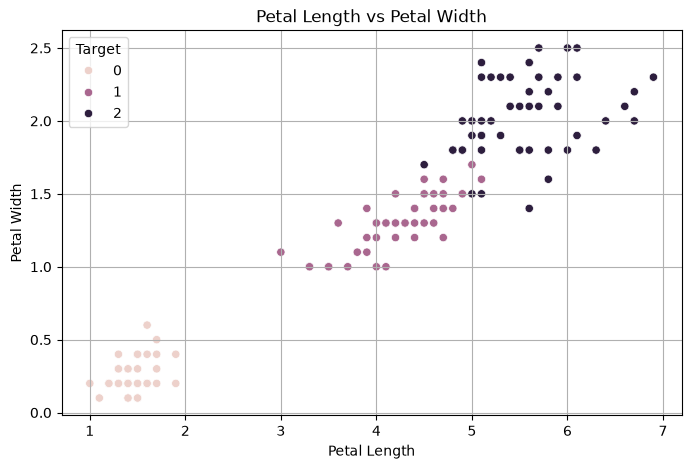

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Petal_Length",
    y="Petal_Width",
    hue="Target"
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.grid(True)

plt.show()

## 7. Feature and Target Selection

The four flower measurements are used as input features, while the Iris species label is used as the target variable.

In [13]:
X = df[
    [
        "Sepal_Length",
        "Sepal_Width",
        "Petal_Length",
        "Petal_Width"
    ]
]

y = df["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


## 8. Train-Test Split

The dataset is divided into training and testing sets.

- **80%** of the data is used for training.
- **20%** is reserved for testing.

Stratified splitting is used so that each Iris class is represented proportionally in both sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 9. Feature Scaling

Standardization is applied to the input features so that they have a similar scale.

The `StandardScaler` transforms the features using their mean and standard deviation. Scaling can help the neural network train more effectively because features with different numerical ranges are brought to a comparable scale.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## 10. Neural Network Architecture

A feed-forward Artificial Neural Network is created using TensorFlow and Keras.

### Architecture

**Input Layer:** 4 neurons corresponding to the four Iris measurements

**Hidden Layer 1:** 16 neurons with ReLU activation

**Hidden Layer 2:** 8 neurons with ReLU activation

**Output Layer:** 3 neurons with Softmax activation, representing the three Iris species.

### Architecture Flow

**Input (4) → Dense (16, ReLU) → Dense (8, ReLU) → Output (3, Softmax)**

In [16]:
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 11. Model Compilation

The neural network is compiled using the Adam optimizer and sparse categorical cross-entropy loss function.

The **Adam optimizer** adjusts the model's weights during training, while **sparse categorical cross-entropy** is appropriate because the target classes are represented using integer labels.

Accuracy is used as the main performance metric.

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## 12. Model Training

The neural network is trained using the scaled training data. The model is trained for **50 epochs** with a batch size of **16**.

A validation split of 20% is used from the training data to monitor how well the model generalizes during training.

In [18]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5833 - loss: 0.9888 - val_accuracy: 0.5417 - val_loss: 0.9961
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6354 - loss: 0.9476 - val_accuracy: 0.5833 - val_loss: 0.9596
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6667 - loss: 0.9092 - val_accuracy: 0.5833 - val_loss: 0.9271
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6771 - loss: 0.8736 - val_accuracy: 0.5833 - val_loss: 0.8987
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6771 - loss: 0.8415 - val_accuracy: 0.5833 - val_loss: 0.8723
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6771 - loss: 0.8132 - val_accuracy: 0.5833 - val_loss: 0.8456
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6875 - loss: 0.7860 - val_accuracy: 0.5833 - val_loss: 0.8197
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6979 - loss: 0.7606 - val_accuracy: 0.5833 - val_loss: 0.7943
Epoch 9

## 13. Training Performance — Accuracy

Training and validation accuracy are plotted to observe how the classification performance changes across the training epochs.

Training accuracy represents the performance of the model on the training data, while validation accuracy represents its performance on previously unseen validation samples.

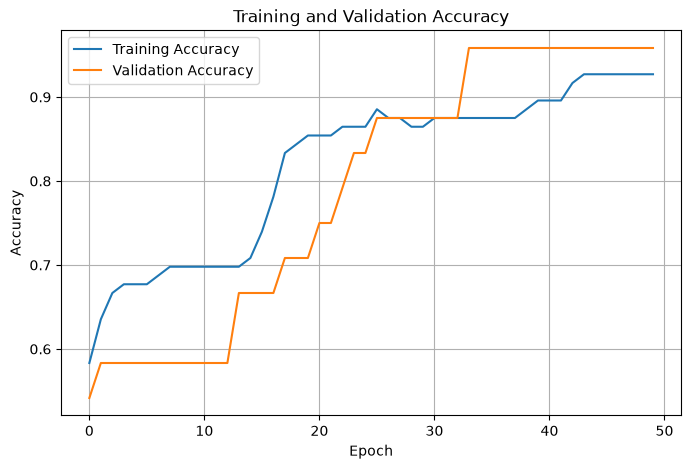

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "Task5_Accuracy_Graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Training Performance — Loss

Training and validation loss are plotted to observe how the model's prediction error changes during training.

A decreasing loss generally indicates that the neural network is learning better representations of the input data.

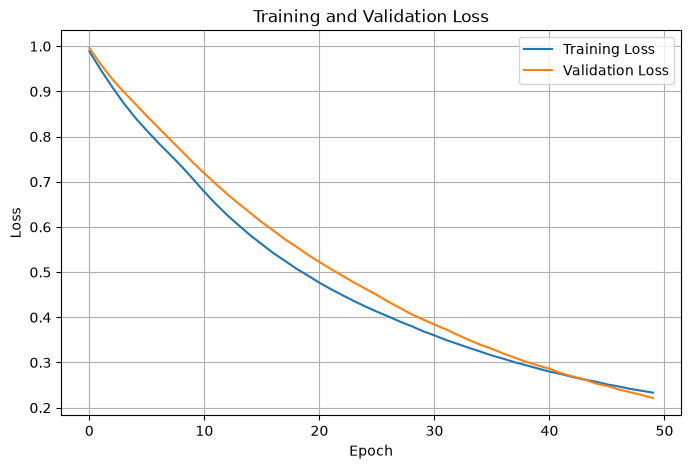

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "Task5_Loss_Graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Model Evaluation

After training, the neural network is evaluated using the separate test dataset. The test dataset was not used during model training and therefore provides an estimate of how well the model performs on unseen data.

In [21]:

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 90.00%
Test Loss: 0.2810


## 16. Model Predictions

The trained neural network produces a probability for each of the three Iris classes. The class with the highest probability is selected as the final predicted class.

In [22]:
y_prob = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(y_prob, axis=1)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 30


## 17. Actual vs Predicted Values

The actual class labels are compared with the predictions generated by the neural network.

In [23]:
results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})

results

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,2
6,0,0
7,0,0
8,2,2
9,1,2


## 18. Sample Predictions

The following examples compare the actual Iris species with the species predicted by the neural network.

In [24]:
target_names = iris.target_names

for i in range(5):
    print(
        f"Example {i+1}: "
        f"Actual = {target_names[y_test.iloc[i]]}, "
        f"Predicted = {target_names[y_pred[i]]}"
    )

Example 1: Actual = setosa, Predicted = setosa
Example 2: Actual = virginica, Predicted = virginica
Example 3: Actual = versicolor, Predicted = versicolor
Example 4: Actual = versicolor, Predicted = versicolor
Example 5: Actual = setosa, Predicted = setosa


## 19. Confusion Matrix

A confusion matrix is used to visualize the classification performance of the neural network across the three Iris species.

The rows represent the actual classes, while the columns represent the predicted classes. Correct predictions appear along the diagonal, while incorrect predictions appear outside the diagonal.

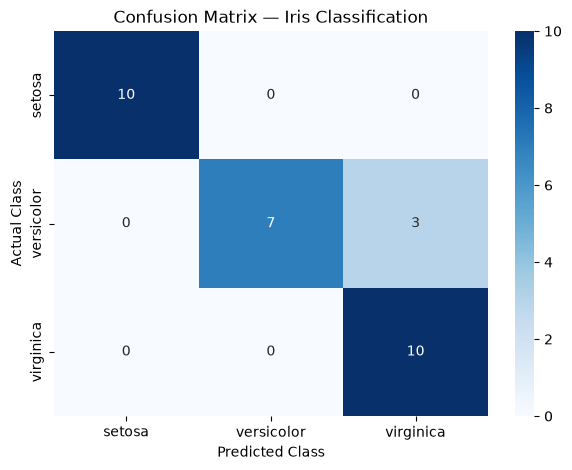

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix — Iris Classification")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.savefig(
    "Task5_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Classification Report

The classification report provides precision, recall, and F1-score for each Iris species. These metrics provide a more detailed evaluation than accuracy alone.

In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.70      0.82        10
   virginica       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



## 21. Results and Discussion

The trained Artificial Neural Network achieved a **test accuracy of 90%** on the 30 unseen Iris test samples. This indicates that the model was able to correctly classify most of the flowers into their respective species.

The model performed perfectly on the **Iris setosa** class, achieving a precision, recall, and F1-score of **1.00**. This indicates that setosa was clearly distinguishable from the other two species.

For **Iris versicolor**, the model achieved a precision of **1.00**, recall of **0.70**, and F1-score of **0.82**. The lower recall indicates that some actual versicolor samples were classified as another species.

For **Iris virginica**, the model achieved a precision of **0.77**, recall of **1.00**, and F1-score of **0.87**. The perfect recall shows that all actual virginica samples were identified, although some flowers predicted as virginica belonged to another class.

Overall, the model achieved a macro-average precision of **0.92**, recall of **0.90**, and F1-score of **0.90**. These results demonstrate that the neural network successfully learned meaningful patterns from the four flower measurements.

## 22. Limitations

Although the neural network achieved 90% test accuracy, the project has some limitations.

1. The Iris dataset is relatively small, containing only 150 samples.
2. The dataset contains only four numerical features.
3. Some characteristics of versicolor and virginica overlap, making them more difficult to distinguish.
4. The neural network architecture is relatively simple and contains only two hidden layers.
5. The model was trained for a fixed number of epochs without extensive hyperparameter tuning.
6. The model was evaluated using a single train-test split, so results may vary with a different split.

## 23. Future Improvements

The performance of the neural network could potentially be improved through several approaches:

1. Increase the amount of training data to improve generalization.
2. Perform hyperparameter tuning for the number of neurons, learning rate, batch size, and number of epochs.
3. Experiment with different neural network architectures.
4. Use techniques such as Dropout or Early Stopping to improve generalization.
5. Compare the neural network with other classification algorithms such as Random Forest, Support Vector Machine, or Logistic Regression.
6. Perform cross-validation to obtain a more reliable estimate of model performance.

## 24. Conclusion

This mini project successfully demonstrated the use of an Artificial Neural Network for classifying Iris flowers into three species: setosa, versicolor, and virginica.

The complete workflow included dataset exploration, feature selection, train-test splitting, feature scaling, neural network architecture design, model compilation, training, prediction, and evaluation.

The final neural network achieved a **90% test accuracy**, demonstrating that a relatively simple ANN can effectively learn classification patterns from numerical data. The model performed particularly well on the setosa class, while some confusion remained between versicolor and virginica.

The project provided practical experience with **TensorFlow, Keras, neural network training, validation, performance visualization, predictions, and confusion matrix analysis**. Further improvements such as hyperparameter tuning, additional data, cross-validation, and alternative architectures could potentially improve the model's performance.

In [27]:
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 90.00%
Test Loss: 0.2810


# Task 5 Report — Iris Neural Network Classification

## Problem Statement

The objective of this project was to develop an Artificial Neural Network (ANN) capable of classifying Iris flowers into three species: Iris setosa, Iris versicolor, and Iris virginica. The classification was based on four measurements: sepal length, sepal width, petal length, and petal width.

## Dataset and Preprocessing

The Iris dataset contains 150 samples and three classes, with 50 samples belonging to each species. The dataset was divided into 80% training data and 20% testing data using stratified sampling. StandardScaler was used to standardize the numerical features before training the neural network.

## Neural Network Architecture

The model was implemented using TensorFlow and Keras. It consisted of an input layer with four features, followed by two hidden layers containing 16 and 8 neurons respectively. Both hidden layers used the ReLU activation function. The output layer contained three neurons with Softmax activation to produce probabilities for the three flower classes. The model was trained using the Adam optimizer and sparse categorical cross-entropy loss for 50 epochs with a batch size of 16.

## Results

The trained neural network achieved a **test accuracy of 90.00%** and a **test loss of 0.2810**. The classification report produced a macro-average precision of **0.92**, recall of **0.90**, and F1-score of **0.90**. The model classified Iris setosa particularly well, achieving precision, recall, and F1-score of 1.00. Versicolor achieved an F1-score of 0.82, while virginica achieved an F1-score of 0.87. The lower recall for versicolor indicates that some versicolor flowers were incorrectly classified as another species.

## Limitations and Future Improvements

The dataset is relatively small, and some characteristics of versicolor and virginica overlap. The model could be improved through hyperparameter tuning, additional training data, cross-validation, early stopping, dropout, and experimentation with different network architectures.

## Conclusion

The project successfully demonstrated the complete deep learning workflow from data preprocessing to neural network training and evaluation. With a test accuracy of 90%, the ANN was effective at classifying Iris flowers and provided practical experience with TensorFlow, Keras, model training, prediction, and evaluation techniques.
